In [968]:
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [ ]:
orignal = cv2.imread(r"D:\hady\3nd year\Second_term\Cognitive\project\bender-gestalt-analysis\data\rraw_drawings\page-00077.jpg")
raw_img =cv2.imread(r"D:\hady\3nd year\Second_term\Cognitive\project\bender-gestalt-analysis\data\processed_drawings\page-00077.jpg",0)
img = cv2.imread(r"D:\hady\3nd year\Second_term\Cognitive\project\bender-gestalt-analysis\data\processed_drawings\page-00077.jpg",0)

In [ ]:

def display_img(img):
  plt.imshow(img, cmap='gray')
  plt.axis("off")
  plt.show()

def upload_img(title, img):
    cv2.imwrite(title, img)

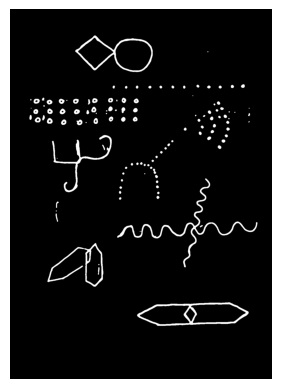

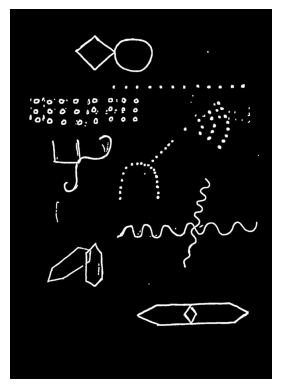

In [971]:
img = cv2.medianBlur(img,9)
display_img(img)
display_img(raw_img)


In [972]:
contours, hierarchy = cv2.findContours(
    img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 114


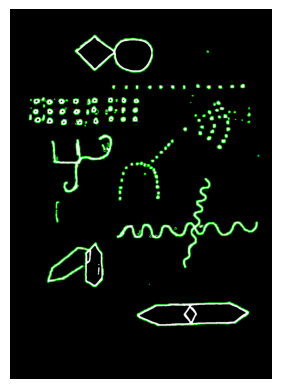

In [973]:
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cv2.drawContours(img_color, contours, -1, (0,255,0), 2)
display_img(img_color)

In [974]:

kernel = np.ones((12,12), np.uint8) 
dilated_img = cv2.dilate(img, kernel, iterations=3)
contours, _ = cv2.findContours(dilated_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

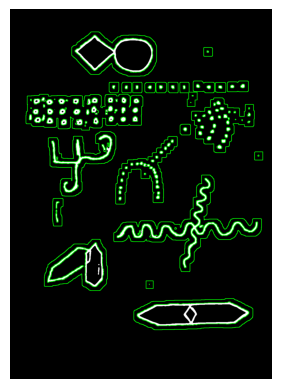

In [975]:
cv2.drawContours(img_color, contours, -1, (0,255,0), 2)
display_img(img_color)

In [976]:
filtered_contours = []

for cnt in contours:

    area = cv2.contourArea(cnt)


    if area > 7000:
        filtered_contours.append(cnt)

print("Filtered:", len(filtered_contours))

Filtered: 8


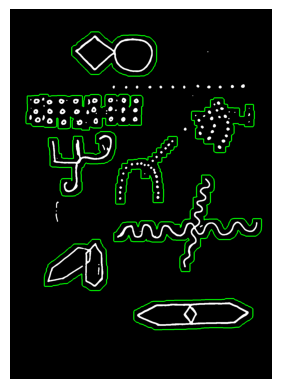

In [977]:
result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cv2.drawContours(result, filtered_contours, -1, (0,255,0), 3)

display_img(result)

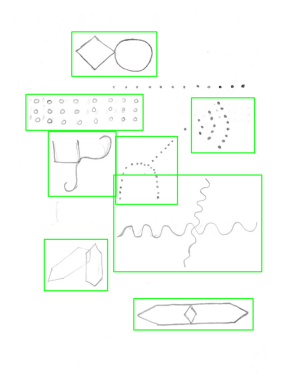

In [ ]:
img_copy = orignal.copy()

for i, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    
    # رسم المستطيل الأخضر للتأكد
    cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 3)
    
    # قص الشكل وحفظه كصورة مستقلة
    roi = img[y:y+h, x:x+w]
    cv2.imwrite(f'shape_{i}.jpg', roi)

display_img(img_copy)